# Assignment 1: Evaluating Language Technologies
This assignment must be completed in order to be considered for enrollment in the class. If you are already enrolled, failure to complete this assignment will result in your removal from the course.

## Introduction
In this assignment, we will explore different tasks core to the field of NLP. You will implement different evaluation metrics for these tasks and perform analysis of different language
technologies.

Learning objectives:
* Understand the breadth of tasks core to the field of NLP.
* Implement various evaluation methods for core NLP tasks.
* Become familiar with prompting existing LLMs via API calls.
* Identify the limitations of automatic evaluation methods.
* Practice using error analysis to identify where language technologies fail and hypothesizing why they might fail.
* Appreciate things we humans do with language that current language models cannot do.

**Notes:**
* In your solution, keep all code as-is except where it's explicitly mentioned to implement a function.
* Items marked with a star (★) should be answered in markdown text in the notebook. You will include your final notebook as a pdf with your submission.
* Results are written to the `results/` sub-directory as you go, and these are what get autograded.

**Submission:**

When you are done, run `python3 make_submission.py`. It checks that every file the
notebook should have written is present, valid, and actually filled in, then packs
them into `submission.zip` for you to upload to gradescope. Two things go in it:

* All the json files saved inside the `results/` directory. These will be autograded.
* A PDF copy of your completed notebook, titled "HW1.pdf". This is used to grade your answers to the problems marked with a (★), so check that your plots rendered before exporting.

**Setup:**
You will need to download ollama https://ollama.com and install the following models with the commands:

`ollama pull qwen3:8b`

`ollama pull llama3.2:1b`

`ollama pull llama3.2`

`ollama pull gemma3:1b`

`ollama pull gemma3:4b`

You will need about 13GB of storage to download these models. Make sure the ollama binary is in /usr/local/bin/ or you know where it is, so you can call it on the command line.

## Running on Google Colab

Set **Runtime → Change runtime type → GPU**, then run the cell below once. It
clones the repo, installs everything, points your inference cache at Drive so a
disconnect can't throw away work, and starts ollama.

Running on your own machine instead? The cell does nothing — follow the README.

In [1]:
# Colab setup. On a local machine this cell is a no-op.
import sys

if "google.colab" in sys.modules:
    import os, subprocess, time

    STUDENT_REPO = "https://github.com/zinengtang/cs183-fall26-a1.git"
    DRIVE_DIR = "/content/drive/MyDrive/cs183-a1"

    # 1. code and data, since opening a notebook from GitHub brings only the notebook
    if not os.path.exists("/content/repo"):
        subprocess.run(["git", "clone", "-q", STUDENT_REPO, "/content/repo"], check=True)
    os.chdir("/content/repo")

    # 2. dependencies (ffmpeg is already on Colab). Capture rather than -q: a bare
    #    CalledProcessError tells you nothing about which package refused to install.
    installed = subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"],
                               capture_output=True, text=True)
    if installed.returncode != 0:
        print(installed.stdout[-2000:])
        print(installed.stderr[-2000:])
        raise RuntimeError("pip install failed -- see the output above for which package and why")

    # 3. keep generations and results on Drive -- the runtime's own disk does not
    #    survive a disconnect, and re-running inference costs far more than this does
    from google.colab import drive
    drive.mount("/content/drive")
    for sub in ("inference_cache", "results"):
        os.makedirs(f"{DRIVE_DIR}/{sub}", exist_ok=True)
        subprocess.run(["rm", "-rf", sub], check=True)
        os.symlink(f"{DRIVE_DIR}/{sub}", sub)

    # 4. ollama. Colab has no systemd, so the installer cannot start the server for us.
    #    Only the four small models are pulled here. The 5.2GB judge model that Part 4
    #    needs is pulled at Part 4, so Parts 1-3 are not stuck behind that download.
    #    The installer unpacks a .tar.zst and exits with an error if zstd is missing,
    #    which it is on Colab. There is no .tgz build to fall back to any more.
    if subprocess.run(["apt-get", "install", "-y", "-qq", "zstd"]).returncode != 0:
        subprocess.run(["apt-get", "update", "-qq"], check=False)
        subprocess.run(["apt-get", "install", "-y", "-qq", "zstd"], check=True)

    installer = subprocess.run("curl -fsSL https://ollama.com/install.sh | sh",
                               shell=True, capture_output=True, text=True)
    if installer.returncode != 0:
        print(installer.stdout[-2000:])
        print(installer.stderr[-2000:])
        raise RuntimeError("the ollama installer failed, see the output above for why")

    subprocess.Popen(["ollama", "serve"])
    time.sleep(5)
    for model in ["llama3.2:1b", "llama3.2", "gemma3:1b", "gemma3:4b"]:
        print(f"pulling {model}")
        subprocess.run(["ollama", "pull", model], check=True)

    print("\nReady. Run the rest of the notebook from the top.")
else:
    print("Not on Colab -- see the README for local setup.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
pulling llama3.2:1b
pulling llama3.2
pulling gemma3:1b
pulling gemma3:4b

Ready. Run the rest of the notebook from the top.


## Part 0: Setup

In [2]:
import pandas as pd
from pandas.core.frame import DataFrame
import aiohttp
import asyncio
import json
from tqdm import tqdm
from typing import Dict
import os

# ollama serves requests from a small queue, so firing hundreds at once just builds a
# backlog that runs past aiohttp's 5 minute default timeout. Bound both explicitly.
MAX_CONCURRENT_REQUESTS = 8
REQUEST_TIMEOUT_SECONDS = 600


class OllamaError(RuntimeError):
    pass


def save_results(results, filename):
    with open(filename, "w") as f:
        json.dump(results, f, indent=4)

async def run_inference(model_name, prompt, temperature=0.0, max_tokens=16, session=None):
    """
    curl http://localhost:11434/api/generate -d '{
		"model": "llama3.2",
		"prompt":"Why is the sky blue?",
		"stream": false,
	}'
    """
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        # Reasoning models spend their whole token budget thinking before they answer,
        # which for a 16-token judge call means an empty response. Models without a
        # thinking mode ignore this.
        "think": False,
        "options": {
            "temperature": temperature,
            "num_predict": max_tokens,
        },
    }

    async def _post(open_session):
        async with open_session.post("http://localhost:11434/api/generate", json=payload) as response:
            if response.status != 200:
                # e.g. a model that has not been pulled yet answers 404 with an error
                # payload, whose .get("response", "") is an empty string -- silently
                # caching those looks exactly like a model that scores zero.
                raise OllamaError(f"ollama returned {response.status}: {(await response.text())[:200]}")
            result = await response.json()
            if "error" in result:
                raise OllamaError(result["error"])
            return result.get("response", "")

    if session is not None:
        return await _post(session)
    timeout = aiohttp.ClientTimeout(total=REQUEST_TIMEOUT_SECONDS)
    async with aiohttp.ClientSession(timeout=timeout) as new_session:
        return await _post(new_session)

async def run_batch_inference(model_name, prompts, temperature=0.0, max_tokens=16):
    progress = tqdm(total=len(prompts))
    semaphore = asyncio.Semaphore(MAX_CONCURRENT_REQUESTS)
    failures = []

    timeout = aiohttp.ClientTimeout(total=REQUEST_TIMEOUT_SECONDS)
    async with aiohttp.ClientSession(timeout=timeout) as session:
        async def _run_inference(prompt):
            async with semaphore:
                try:
                    result = await run_inference(model_name, prompt, temperature, max_tokens, session=session)
                except Exception as e:
                    # returning None instead of raising keeps one bad request from
                    # discarding every other result in the batch
                    failures.append(f"{type(e).__name__}: {e}")
                    result = None
                progress.update(1)
                return result
        results = await asyncio.gather(*[_run_inference(prompt) for prompt in prompts])

    if failures:
        print(f"{len(failures)}/{len(prompts)} requests to {model_name} failed and were not cached; "
              f"re-run this cell to retry them. First failure: {failures[0]}")
    return results

def cache_inferences(model_name, exp_name, prompts, inferences):
    # skip failed requests so they are retried rather than cached as missing answers
    fresh = {prompt: inference for prompt, inference in zip(prompts, inferences) if inference is not None}
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            cache.update(fresh)
    else:
        cache = fresh
    with open(f"inference_cache/{model_name}_{exp_name}.json", "w") as f:
        json.dump(cache, f)

def load_inferences(model_name, exp_name, prompts):
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            return [cache[prompt] if prompt in cache else None for prompt in prompts]
    return [None for _ in prompts]

def get_remaining_prompts(model_name, exp_name, prompts):
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            return [prompt for prompt in prompts if prompt not in cache]
    return prompts

models = [
    "llama3.2:1b" ,
    "llama3.2",
    "gemma3:1b",
    "gemma3:4b",
]

## Part 1: Text classification (25 points)
Here, we will evaluate different LLMs on their ability to perform newsgroup classification. You will implement four standard metrics for evaluating a classifier and create a visualization of the errors using a confusion matrix. We will be using a classic NLP dataset, 20 Newsgroups (http://qwone.com/~jason/20Newsgroups/).

### Part 1.0: Setup
Load the data we will be using for evaluation. This is the development set of the dataset, so it's ok for us to do analysis with it.

We will load the possible labels from the training set, rather than the development set. If a new label has to be predicted at test-time, we wouldn't have learned it from training only on the training set!

In [3]:
classification_inputs = pd.read_csv('A1_Data/dev_data.csv')
classification_labels = pd.read_csv('A1_Data/dev_labels.csv')
classification_data = pd.merge(classification_inputs, classification_labels, on="id", how="inner")[:200]

print(f"Loaded newsgroup data of shape {classification_data.shape} with columns {classification_data.columns.tolist()}.")

labels = pd.read_csv('A1_Data/train_labels.csv')["newsgroup"].unique()
label_list = ", ".join(sorted(list(labels)))

print(f"Found {len(labels)} possible target labels: ")
print(label_list)


def normalize_prediction(text):
	"""Clean a raw model response up so it can be compared against a label.

	Model output is not guaranteed to be exactly one of the newsgroup names.
	Responses here routinely carry a trailing newline, and a model that ignores
	the "no other text" instruction may wrap the label in something longer.
	Deciding how to read a model's answer is part of the evaluation, not a
	detail -- for one of these models, skipping this step more than halves its
	measured accuracy.
	"""
	if text is None:
		# the request failed and was not cached -- re-run the inference cell to retry it
		return ""
	return text.strip()

Loaded newsgroup data of shape (200, 3) with columns ['id', 'text', 'newsgroup'].
Found 20 possible target labels: 
alt.atheism, comp.graphics, comp.os.ms-windows.misc, comp.sys.ibm.pc.hardware, comp.sys.mac.hardware, comp.windows.x, misc.forsale, rec.autos, rec.motorcycles, rec.sport.baseball, rec.sport.hockey, sci.crypt, sci.electronics, sci.med, sci.space, soc.religion.christian, talk.politics.guns, talk.politics.mideast, talk.politics.misc, talk.religion.misc


Now let's run inference with the different classifiers. It will take some time to run inference.

If you cannot get ollama running, `inference_cache_reference/` holds our own generations for Parts 1, 3 and 4.0 — copy them into `inference_cache/` and the cells below will use those. Say so in your writeup if you do, and note that Part 4's judge is not cached, so 4.1, 4.2 and 4.4 need a working ollama regardless.

In [4]:
def get_newsgroup_prompt(text):
	newsgroup_prompt = "In which of the following newsgroups is the following email most likely to appear? Output only the newsgroup name, no other text."
	newsgroup_prompt += f"\n\nNewsgroups:\n{label_list}\n\nEmail:\n{text}"
	return newsgroup_prompt

prompts = [get_newsgroup_prompt(text) for text in classification_data["text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt1_0_classification_data", prompts)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=16)
	cache_inferences(model, "pt1_0_classification_data", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt1_0_classification_data", prompts)
	classification_data[f"predictions_{model}"] = inferences

Running inference for llama3.2:1b


0it [00:00, ?it/s]


Running inference for llama3.2


0it [00:00, ?it/s]


Running inference for gemma3:1b


0it [00:00, ?it/s]


Running inference for gemma3:4b


0it [00:00, ?it/s]


In [5]:
classification_data

,id,text,newsgroup,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,From: tim@kimba.catt.citri.edu.au (Tim Liddelo...,comp.windows.x,talk.politics.misc,comp.sys.ibm.pc.hardware,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
1,1,From: petrack@vnet.IBM.COM\nSubject: disabling...,comp.sys.mac.hardware,talk.politics.misc,talk.politics.misc,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
2,2,From: Lars.Jorgensen@p7.syntax.bbs.bad.se (Lar...,comp.graphics,talk.politics.misc,talk.religion.misc,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
3,3,From: dnh@mfltd.co.uk (Des Herriott)\nSubject:...,comp.windows.x,talk.politics.misc,talk.politics.misc,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
4,4,From: willisw@willisw.ENG.CLEMSON.edu (Bill Wi...,comp.sys.ibm.pc.hardware,talk.politics.guns,talk.religion.misc,alt.comp.graphics,comp.os.ms-windows.misc\n
...,...,...,...,...,...,...,...
195,195,From: fox@graphics.cs.nyu.edu (David Fox)\nSub...,soc.religion.christian,talk.politics.misc,alt.atheism,alt.atheism,alt.atheism\n
196,196,From: moor9881@mach1.wlu.ca (Dwayne Moore u)\n...,comp.os.ms-windows.misc,talk.politics.misc,comp.sys.ibm.pc.hardware,rec.motorscycles\n,comp.os.ms-windows.misc\n
197,197,From: nsmca@aurora.alaska.edu\nSubject: Re: ar...,sci.space,sci.electronics,talk.politics.military,rec.motorscycles,talk.politics.guns\n
198,198,From: ohayon@jcpltyo.JCPL.CO.JP (Tsiel Ohayon)...,talk.politics.mideast,talk.politics.guns,talk.politics.misc,rec.sport\n,alt.atheism\n


### Part 1.1: Confusion Matrix (5 points)
Complete the following functions. The first one should computes a confusion matrix for a set of predictions, and the second one should use your favorite tool (e.g. Matplotlib) to visualize it as a heatmap.

We're implementing the confusion matrix first because you might find it useful when completing the rest of Part 1.

If the model messes up the output format (e.g. outputs something that isn't one of the labels), the prediction should not be included in the matrix counts.

In [6]:
def part1_1_cm(x: DataFrame, y: str) -> Dict[str, Dict[str, int]]:
    cm = {}

    # start every possible true/predicted pair at 0
    for true_label in labels:
        cm[true_label] = {}
        for predicted_label in labels:
            cm[true_label][predicted_label] = 0

    prediction_col = f"predictions_{y}"

    for _, row in x.iterrows():
        true_label = row["newsgroup"]
        predicted_label = normalize_prediction(row[prediction_col])

        # ignore outputs that are not valid labels
        if predicted_label in labels:
            cm[true_label][predicted_label] += 1

    return cm


def part_1_1_vis(x: Dict[str, Dict[str, int]]):
    import matplotlib.pyplot as plt

    label_names = sorted(x.keys())
    matrix = []

    for true_label in label_names:
        row = []
        for predicted_label in label_names:
            row.append(x[true_label][predicted_label])
        matrix.append(row)

    plt.figure(figsize=(14, 12))
    plt.imshow(matrix, aspect="auto")
    plt.colorbar()

    plt.xticks(range(len(label_names)), label_names, rotation=90, fontsize=8)
    plt.yticks(range(len(label_names)), label_names, fontsize=8)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")

    plt.tight_layout()
    plt.show()

Now we'll use these functions to compute and visualize confusion matrices for each classifier.

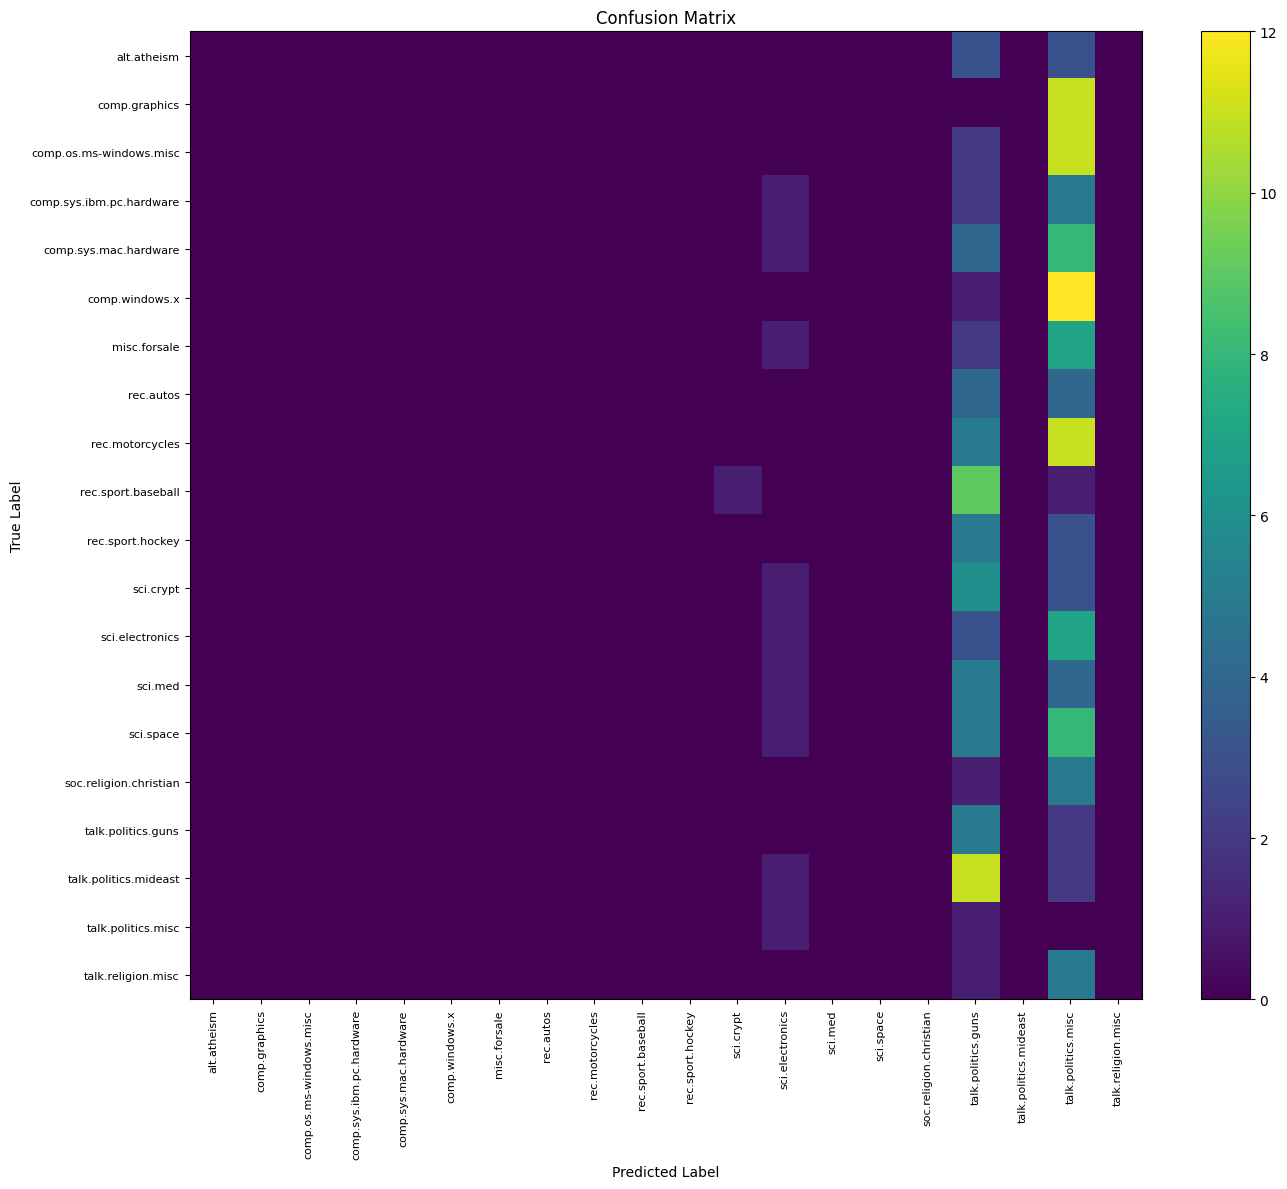

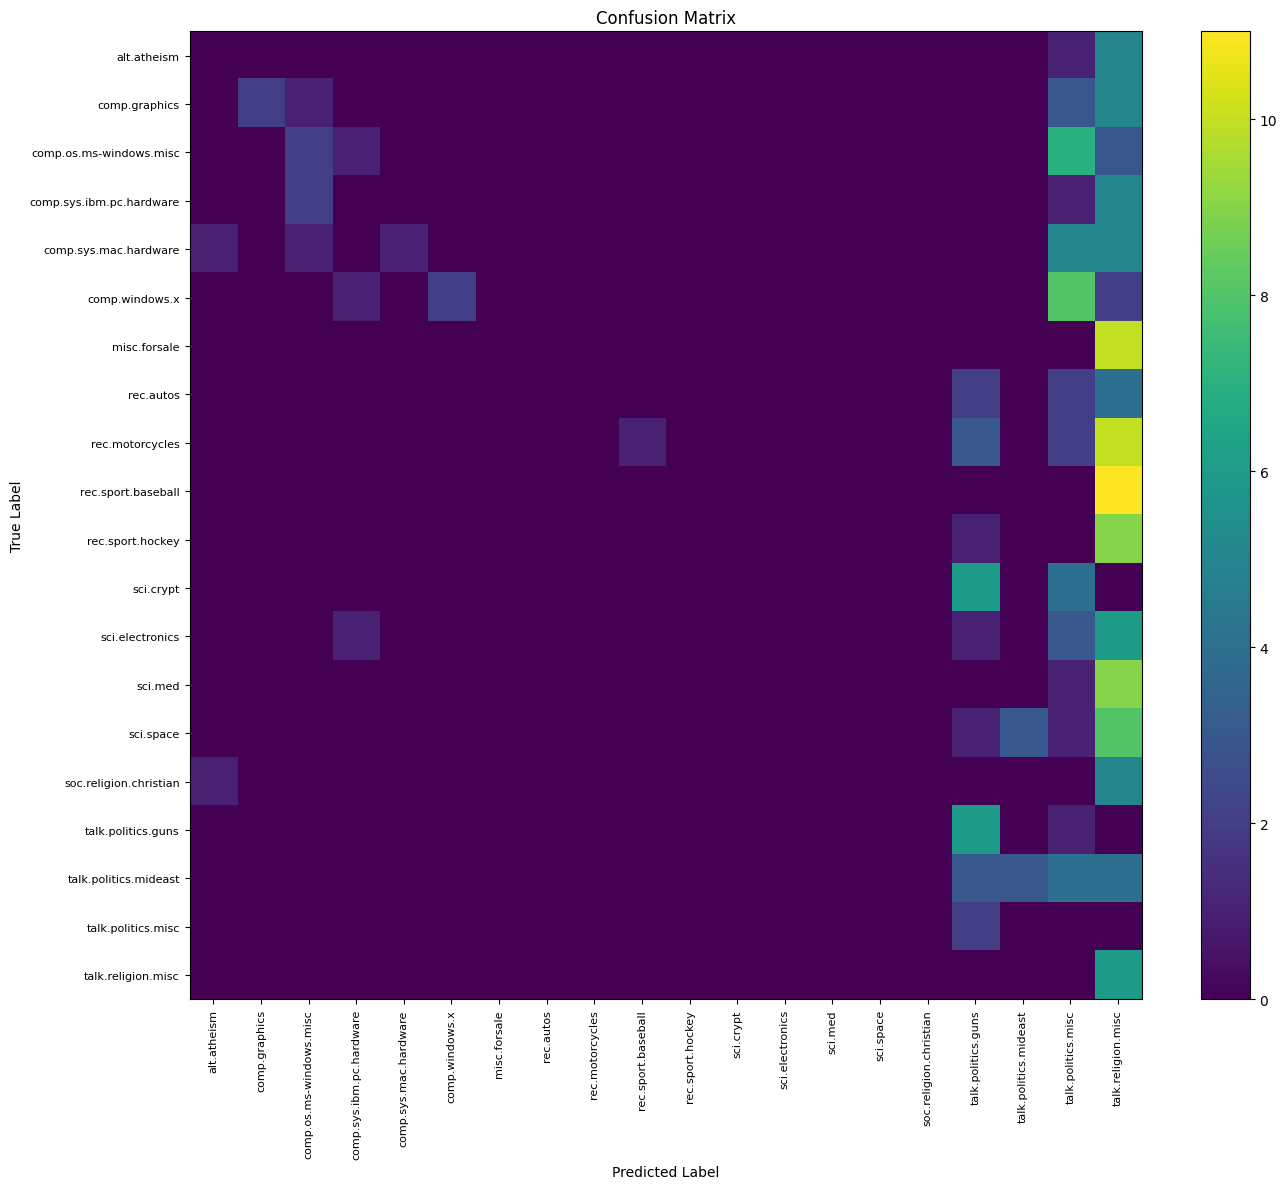

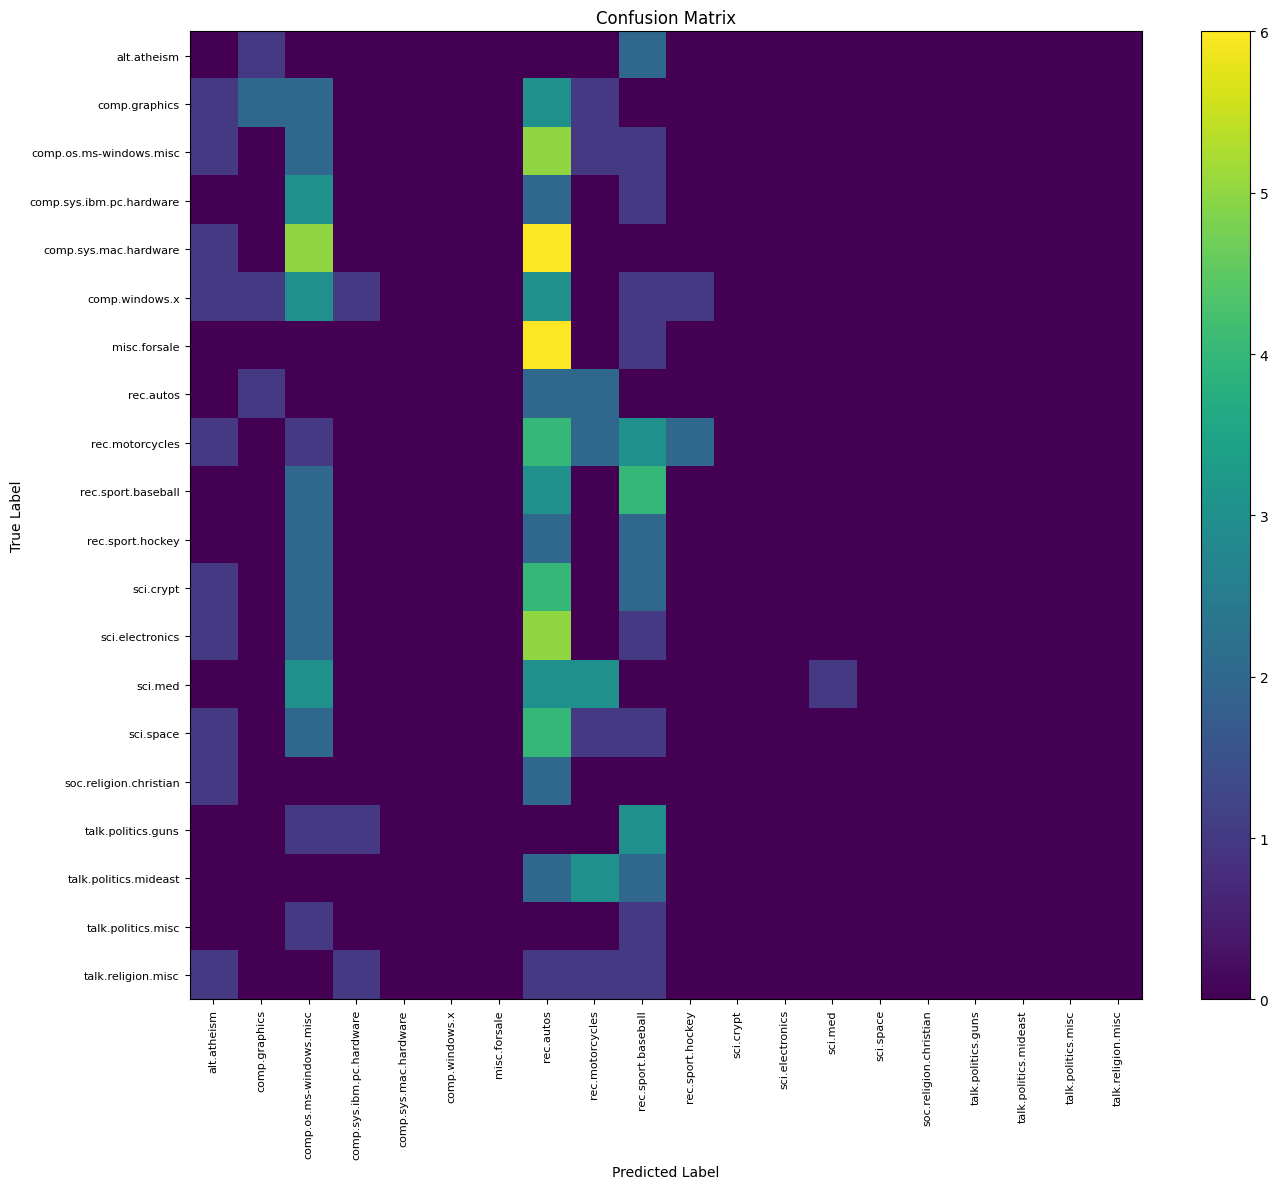

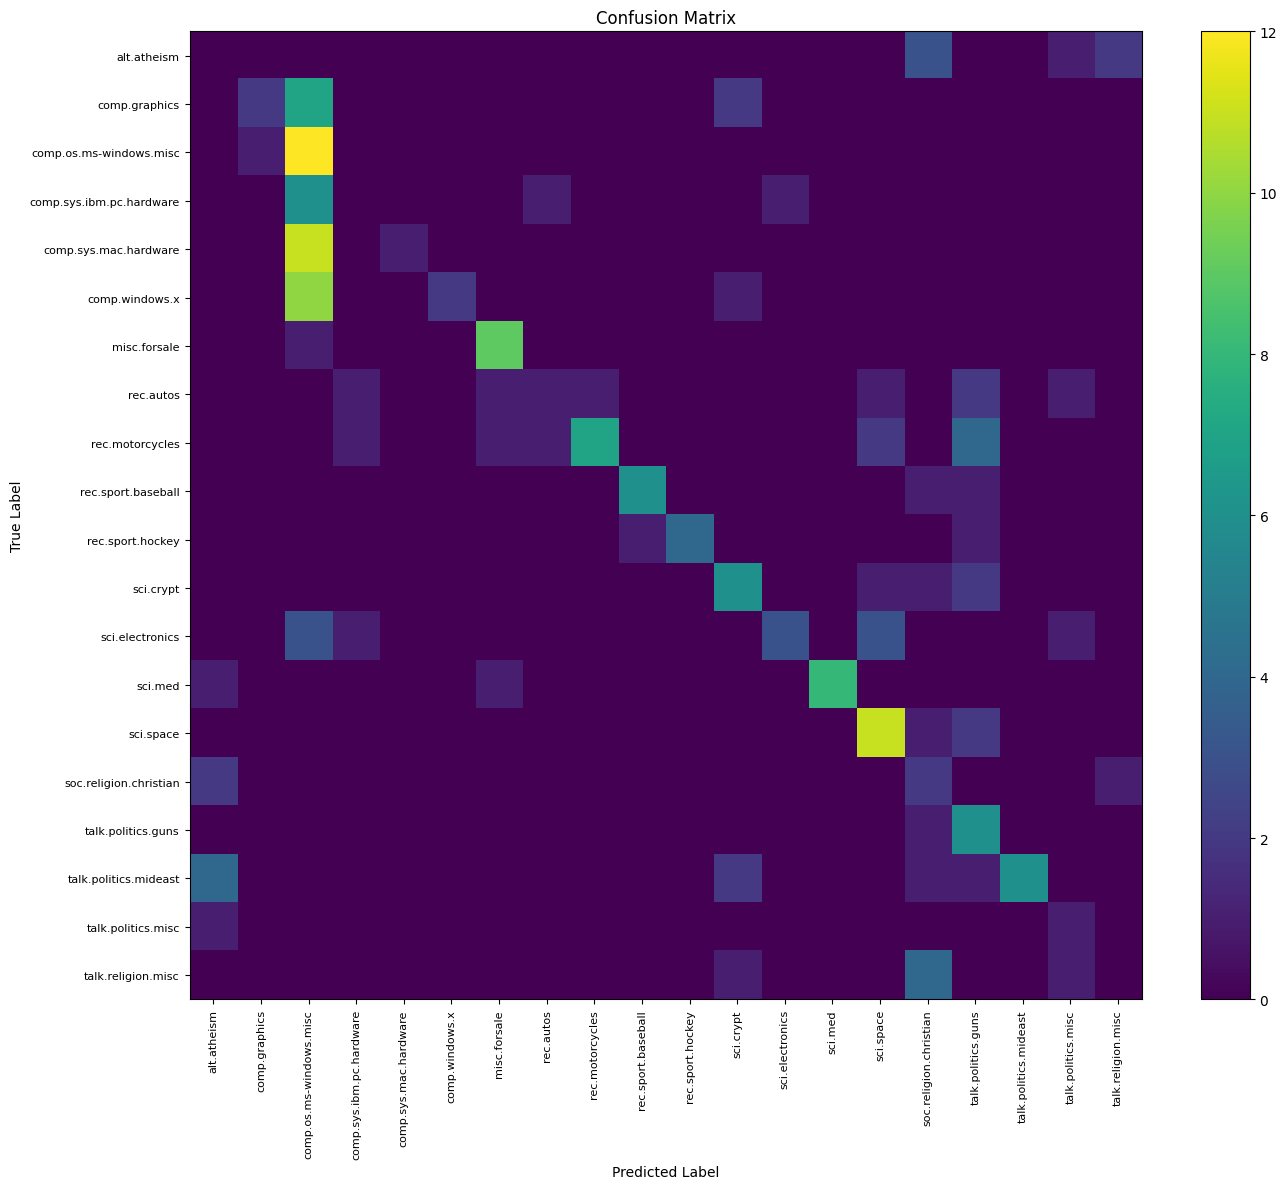

In [7]:
confusion_matrices = dict()

for model in models:
    confusion_matrices[model] = part1_1_cm(classification_data, model)
    part_1_1_vis(confusion_matrices[model])

★ Make sure the images are rendered in the notebook pdf you submit.

★ For each of the different classifiers, which pair of classes is most often confused?

- llama3.2:1b: comp.windows.x -- talk.politics.misc (12 times)
- llama3.2: rec.sport.baseball -- talk.religion.misc (11 times)
- gemma3:1b: comp.sys.mac.hardware -- rec.autos(6 times)
- gemma3:4b: comp.sys.mac.hardware -- comp.os.ms-windows.misc (11 times)

★ Use the scratch space below to explore the documents that are misclassified most often with these class pairings, and include snippets of a few examples below.

For llama3.2:1b, one comp.windows.x example had the subject "Installing MIT X11R5 on Apollo" and asked about building MIT X11R5. Another one had the subject "XDM/xsession woes" and discussed getting xdm running on an X display. Both were predicted as talk.politics.misc.

For llama3.2, one rec.sport.baseball example discussed MLB standings and scores, while another said Nolan Ryan had torn cartilage in his knee and would miss 2– 5 weeks. Both were predicted as talk.religion.misc.

For gemma3:1b, one comp.sys.mac.hardware post discussed a Mac monitor showing vertical lines and possible display memory or video card problems. Another discused a bad hard drive in an LCIII. Both were predicted as rec.autos.

For gemma3:4b, one comp.sys.mac.hardware post asked about turning off power management on a Duo 210. Another discussed problems with a Mac monitor and video card. Then both were predicted as comp.os.ms-windows.misc.

★ Why might these pairs of classes be more difficult for the classifiers to distinguish?

Some of these mistakes probably come from overlapping vocabulary, especially for the computer-related classes. A post about a Mac can mention displays, memory, hard drives, operating systems, power management, etc, so the model has to understand what the main topic is rather than just matching technical words.

For the weaker models, some of the errors are much stranger. For example, baseball posts being classified as religion or X11 posts being classified as politics don't really seem semantically close. This makes me think those models may be relying too much on a few words or patterns instead of understanding the overall topic.

In [8]:
# used this for sctatch work

### Part 1.2: Accuracy (5 points)
Complete the following function, then use it to compute and compare the accuracies of each classifier.

Model predictions are raw text, not clean labels. Pass each one through
`normalize_prediction` (defined in Part 1.0) before comparing it to the ground
truth, and do it consistently across Parts 1.1 through 1.5 -- comparing the raw
strings scores at least one of these models far below its real accuracy.

A prediction that is still not one of the labels after normalising counts as
incorrect in Parts 1.2 through 1.5. Part 1.1 is the exception: a confusion
matrix has no cell to put it in, so it is left out of the counts there.

★ Generate a table comparing the accuracy of each of the classifier systems.

I did this 2 cells below.

Model	Accuracy

0	llama3.2:1b	0.030

1	llama3.2	0.110

2	gemma3:1b	0.065

3	gemma3:4b	0.435

★ Which one has the highest accuracy?

gemma3:4b has the highest accuracy by a wide margin at 0.435/43.5%.

In [9]:
def part1_2_acc(x: DataFrame, y: str) -> float:
    correct = 0
    prediction_col = f"predictions_{y}"

    for _, row in x.iterrows():
        predicted = normalize_prediction(row[prediction_col])
        actual = row["newsgroup"]

        if predicted == actual:
            correct += 1

    return correct / len(x)


accuracies: dict[str, float] = dict()

for model in models:
    accuracies[model] = part1_2_acc(classification_data, model)

save_results(accuracies, "results/accuracies.json")
best_model = max(accuracies, key=accuracies.get)

In [10]:
accuracy_table = pd.DataFrame({
    "Model": list(accuracies.keys()),
    "Accuracy": list(accuracies.values())})

accuracy_table

,Model,Accuracy
0,llama3.2:1b,0.030
1,llama3.2,0.110
2,gemma3:1b,0.065
3,gemma3:4b,0.435


### Part 1.3: Precision (5 points)
Complete the following function that returns, for each class, the precision of the classifier's labels given ground-truth labels. (note: if there are no predictions for a given class, then precision should be 0)

★ Generate a table showing, for the best-performing classifier, the precision of its labels across each class.

I did this 2 cells below, pasted again for reference:
Class	Precision

0	sci.med	1.000000

16	comp.windows.x	1.000000

8	comp.sys.mac.hardware	1.000000

4	talk.politics.mideast	1.000000

15	rec.sport.hockey	1.000000

2	rec.motorcycles	0.875000

9	rec.sport.baseball	0.857143

3	sci.electronics	0.750000

19	misc.forsale	0.750000

12	comp.graphics	0.666667

11	sci.space	0.611111

10	sci.crypt	0.500000

1	rec.autos	0.333333

18	talk.politics.guns	0.315789

6	comp.os.ms-windows.misc	0.240000

7	talk.politics.misc	0.200000

14	soc.religion.christian	0.142857

5	comp.sys.ibm.pc.hardware	0.000000

13	alt.atheism	0.000000

17	talk.religion.misc	0.000000


★ For which class are its labels the most accurate? The least?

The highest precision is 1.0. Many classes tie for the highest precision, including sci.med, comp.windows.x, comp.sys.mac.hardware, talk.politics.mideast, and rec.sport.hockey.

The lowest precision is 0.0. comp.sys.ibm.pc.hardware, alt.atheism, and talk.religion.misc all tie for the lowest.

In [11]:
def part1_3_prec(x: DataFrame, y: str) -> dict[str, float]:
    precision = {}
    prediction_col = f"predictions_{y}"

    for curr_label in labels:
        true_positive = 0
        predicted_total = 0
        for _, row in x.iterrows():
            predicted = normalize_prediction(row[prediction_col])
            actual = row["newsgroup"]

            if predicted == curr_label:
              predicted_total += 1
              if actual == curr_label:
                true_positive += 1

        if predicted_total == 0: precision[curr_label] = 0
        else: precision[curr_label] = true_positive / predicted_total

    return precision

if best_model not in models:
    print(f"best_model is still {best_model!r}. Set it in Part 1.2 to one of {models}, "
          f"then re-run this cell.")
    best_model_prec = None
else:
    best_model_prec = part1_3_prec(classification_data, best_model)
save_results(best_model_prec, "results/best_model_prec.json")

In [12]:
precision_table = pd.DataFrame({
    "Class": list(best_model_prec.keys()),
    "Precision": list(best_model_prec.values())})

precision_table = precision_table.sort_values("Precision", ascending=False)
precision_table

,Class,Precision
0,sci.med,1.000000
16,comp.windows.x,1.000000
8,comp.sys.mac.hardware,1.000000
4,talk.politics.mideast,1.000000
15,rec.sport.hockey,1.000000
2,rec.motorcycles,0.875000
9,rec.sport.baseball,0.857143
3,sci.electronics,0.750000
19,misc.forsale,0.750000
12,comp.graphics,0.666667


In [13]:
highest_class = max(best_model_prec, key=best_model_prec.get)
lowest_class = min(best_model_prec, key=best_model_prec.get)
print("Highest:", highest_class, best_model_prec[highest_class])
print("Lowest:", lowest_class, best_model_prec[lowest_class])

Highest: sci.med 1.0
Lowest: comp.sys.ibm.pc.hardware 0.0


### Part 1.4: Recall (5 points)
Complete the following function that returns, for each target class, the recall of the classifier's labels. (note: if there are no ground truth labels for a given class, the recall should be 0)

★ Generate a table showing, for each target class, the recall of the best-performing model's labels across each class.

Class	Recall

6	comp.os.ms-windows.misc	0.923077

19	misc.forsale	0.900000

18	talk.politics.guns	0.857143

0	sci.med	0.800000

11	sci.space	0.785714

10	sci.crypt	0.600000

9	rec.sport.baseball	0.545455

7	talk.politics.misc	0.500000

2	rec.motorcycles	0.437500

4	talk.politics.mideast	0.428571

15	rec.sport.hockey	0.363636

14	soc.religion.christian	0.333333

3	sci.electronics	0.272727

12	comp.graphics	0.181818

16	comp.windows.x	0.153846

1	rec.autos	0.125000

8	comp.sys.mac.hardware	0.076923

5	comp.sys.ibm.pc.hardware	0.000000

13	alt.atheism	0.000000

17	talk.religion.misc	0.000000


★ For which class is recall the highest? The lowest?

The highest recall is for comp.os.ms-windows.misc at about 0.923.

The lowest recall is 0.0: comp.sys.ibm.pc.hardware, alt.atheism, and talk.religion.misc all tie for the lowest recall.

In [14]:
def part1_4_rec(x: DataFrame, y: str) -> dict[str, float]:
    recall = {}
    prediction_col = f"predictions_{y}"

    for curr_label in labels:
        correct = 0
        actual_total = 0

        for _, row in x.iterrows():
            actual = row["newsgroup"]
            predicted = normalize_prediction(row[prediction_col])

            if actual == curr_label:
                actual_total += 1
                if predicted == curr_label:
                    correct += 1

        if actual_total == 0: recall[curr_label] = 0
        else: recall[curr_label] = correct / actual_total
    return recall

if best_model not in models:
    print(f"best_model is still {best_model!r}. Set it in Part 1.2 to one of {models}, "
          f"then re-run this cell.")
    best_model_rec = None
else:
    best_model_rec = part1_4_rec(classification_data, best_model)

save_results(best_model_rec, "results/best_model_rec.json")

In [15]:
recall_table = pd.DataFrame({
    "Class": list(best_model_rec.keys()),
    "Recall": list(best_model_rec.values())})

recall_table = recall_table.sort_values("Recall", ascending=False)
recall_table

,Class,Recall
6,comp.os.ms-windows.misc,0.923077
19,misc.forsale,0.900000
18,talk.politics.guns,0.857143
0,sci.med,0.800000
11,sci.space,0.785714
10,sci.crypt,0.600000
9,rec.sport.baseball,0.545455
7,talk.politics.misc,0.500000
2,rec.motorcycles,0.437500
4,talk.politics.mideast,0.428571


In [16]:
highest_recall = max(best_model_rec.values())
lowest_recall = min(best_model_rec.values())
print("Highest recall:", highest_recall)
print("Classes:", [c for c in best_model_rec if best_model_rec[c] == highest_recall])
print("Lowest recall:", lowest_recall)
print("Classes:", [c for c in best_model_rec if best_model_rec[c] == lowest_recall])

Highest recall: 0.9230769230769231
Classes: ['comp.os.ms-windows.misc']
Lowest recall: 0.0
Classes: ['comp.sys.ibm.pc.hardware', 'alt.atheism', 'talk.religion.misc']


### Part 1.5: F1 (5 points)

A weighted average F1 score computes an average F1 score over all target classes, weighted by the true number of instances of that class:

![test](https://github.com/zinengtang/cs183-fall26-a1/blob/main/A1_Data/f1.png?raw=1)

Here, *f* is a classification function, *C* is the set of classes, *D* is the set of evaluation data with ground-truth labels, and *D_c* is the set of data whose ground-truth label is *c*.

Implement two functions below:
* A function that returns, for a target class, the F1 of a classifier's labels given ground truth labels
* A function that uses the previous function to compute a weighted average F1 score

In [17]:
def part1_5_class_f1(x: DataFrame, y: str, z: str) -> float:
    precision = part1_3_prec(x, y)[z]
    recall = part1_4_rec(x, y)[z]
    if precision + recall == 0:
        return 0
    return 2 * precision * recall / (precision + recall)


def part1_5_weighted_f1(x: DataFrame, y: str) -> float:
    total = len(x)
    weighted_sum = 0

    for curr_label in labels:
        class_count = 0
        for _, row in x.iterrows():
            if row["newsgroup"] == curr_label:
                class_count += 1
        class_f1 = part1_5_class_f1(x, y, curr_label)
        weighted_sum += (class_count / total) * class_f1

    return weighted_sum

★ Generate a table comparing the weighted F1 score of each classifier.


Model	Weighted F1

0	llama3.2:1b	0.009768

1	llama3.2	0.094537

2	gemma3:1b	0.053770

3	gemma3:4b	0.436797


★ Which is the best classifier according to weighted F1? How and why might this differ from an accuracy comparison (Part 1.2)?

gemma3:4b is the best classifier with a score of about 0.437. This is also the model that had the highest accuracy in Part 1.2.

Weighted F1 can differ from accuracy because accuracy just measures the overall fraction of correct predictions, but F1 considers both precision and recall for each class. Especially when a model performs very well on some classes but poorly on others, this matters a lot. Weighted F1  accounts for both false positives and false negatives rather than just total correct predictions.

In [18]:
f1s: dict[str, float] = dict()

for model in models:
    f1s[model] = part1_5_weighted_f1(classification_data, model)

save_results(f1s, "results/f1s.json")

f1_table = pd.DataFrame({
    "Model": list(f1s.keys()),
    "Weighted F1": list(f1s.values())})

f1_table

,Model,Weighted F1
0,llama3.2:1b,0.009768
1,llama3.2,0.094537
2,gemma3:1b,0.053770
3,gemma3:4b,0.436797


## Part 2: Automatic speech recognition (25 points)
Here, we'll explore using a popular open-source automatic speech recognition system to compare its performance across English speakers whose native language differs.

### Part 2.0: Setup
`transcriptions.tsv` ships with the repo, so the cell below only downloads the Speech Accent Archive (https://www.kaggle.com/datasets/rtatman/speech-accent-archive/data) -- an 865MB archive that takes a while to extract -- when those transcripts are missing or incomplete.

In [19]:
import os

# transcriptions.tsv ships with the repo. The 865MB audio archive is only needed
# when it is missing or short, so decide that first and skip the download otherwise.
transcript_counts = {}
if os.path.exists('transcriptions.tsv'):
    with open('transcriptions.tsv') as infile:
        for line in infile:
            language, _, _ = line.rstrip("\n").partition("\t")
            transcript_counts[language] = transcript_counts.get(language, 0) + 1

need_to_transcribe = not transcript_counts or any(n != 20 for n in transcript_counts.values())

if need_to_transcribe:
    import kagglehub
    speech_accent_path = kagglehub.dataset_download("rtatman/speech-accent-archive")
    speakers = pd.read_csv(f"{speech_accent_path}/speakers_all.csv")
    language_counts = speakers['native_language'].value_counts()
    languages_with_over_20_samples = set(language_counts[language_counts >= 20].index)
else:
    languages_with_over_20_samples = set(transcript_counts)

print(f"{len(languages_with_over_20_samples)} languages with at least 20 samples:")
print(sorted(languages_with_over_20_samples))

21 languages with at least 20 samples:
['amharic', 'arabic', 'cantonese', 'dutch', 'english', 'farsi', 'french', 'german', 'italian', 'japanese', 'korean', 'macedonian', 'mandarin', 'polish', 'portuguese', 'romanian', 'russian', 'spanish', 'swedish', 'turkish', 'vietnamese']


If the transcripts do need regenerating, load WhisperX. This might take some time to load.

In [20]:
if need_to_transcribe:
    import whisperx

    # Needs whisperx >= 3.8: 3.4.2 could not load its own VAD against current
    # pyannote-audio, and it also caps out at Python 3.12, which Colab is past.
    whisperx_model = whisperx.load_model("tiny", "cpu", compute_type="float32", language="en")

Now let's run inference. This is the smallest model we could run inference on, so its performance isn't going to be great. But, it shouldn't take *too* long to run on your local machine!

In [21]:
from tqdm import tqdm

transcriptions = {language: list() for language in languages_with_over_20_samples}

if need_to_transcribe:
    recordings_filepath = f"{speech_accent_path}/recordings/recordings/"
    for language in languages_with_over_20_samples:
        print(f"Transcribing for native language {language}...")
        for i in tqdm(range(20)):
            filename = f"{language}{i + 1}.mp3"
            audio = whisperx.load_audio(f"{recordings_filepath}/{filename}")
            transcription = whisperx_model.transcribe(audio, language="en")
            # flatten to text here, so this path and the tsv path agree on the type
            text = " ".join(segment["text"] for segment in transcription["segments"])
            transcriptions[language].append(" ".join(text.split()))

    with open("transcriptions.tsv", "w") as ofile:
        for language, transcripts in transcriptions.items():
            for transcript in transcripts:
                ofile.write(f"{language}\t{transcript}\n")
else:
    with open('transcriptions.tsv') as infile:
        for line in infile:
            # partition rather than split so an empty transcript is still a valid row
            language, _, transcript = line.rstrip("\n").partition("\t")
            if language in transcriptions:
                transcriptions[language].append(transcript)

### Part 2.1: Word error rate (10 points)
Implement the following function to compute the word error rate of a candidate transcription against a reference. It takes the **reference** first and the candidate second, matching the call below. Each of the recordings we transcribed are readings of the same English text: *"Please call Stella.  Ask her to bring these things with her from the store:  Six spoons of fresh snow peas, five thick slabs of blue cheese, and maybe a snack for her brother Bob.  We also need a small plastic snake and a big toy frog for the kids.  She can scoop these things into three red bags, and we will go meet her Wednesday at the train station."*

Compare the two token lists case-insensitively. Whether a transcript writes
*Please* or *please* is a choice the ASR system made about how to render the
words it heard, not a recognition error, so folding case keeps the metric
measuring what it is supposed to measure.

In [22]:
def part2_1(x: list[str], y: list[str]) -> float:
    # make comparison case-insensitive
    reference = [word.lower() for word in x]
    candidate = [word.lower() for word in y]
    # dp[i][j] = minimum edits to turn first i reference tokens
    dp = [[0 for j in range(len(candidate) + 1)]
          for i in range(len(reference) + 1)]
    for i in range(len(reference) + 1):
        dp[i][0] = i
    for j in range(len(candidate) + 1):
        dp[0][j] = j
    for i in range(1, len(reference) + 1):
        for j in range(1, len(candidate) + 1):
            if reference[i - 1] == candidate[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                deletion = dp[i - 1][j]
                insertion = dp[i][j - 1]
                substitution = dp[i - 1][j - 1]
                dp[i][j] = 1 + min(deletion, insertion, substitution)
    return dp[len(reference)][len(candidate)] / len(reference)

Then let's evaluate for all of the candidate transcriptions and each of the native languages.

★ Generate a table comparing the average WER across each of the languages.

Language	Average WER

16	german	0.083766

10	english	0.085714

2	macedonian	0.092857

4	swedish	0.101299

13	romanian	0.109091

15	farsi	0.114286

17	dutch	0.114286

5	polish	0.131169

11	japanese	0.133117


12	french	0.140260

8	arabic	0.141558

6	italian	0.151948

7	portuguese	0.160390

18	russian	0.161039

3	mandarin	0.166883

19	korean	0.172727

20	cantonese	0.175325

0	turkish	0.186364

9	spanish	0.221429

1	amharic	0.227273

14	vietnamese	0.266234


In [23]:
import nltk
nltk.download('punkt_tab')

reference = "Please call Stella.  Ask her to bring these things with her from the store: " \
            "Six spoons of fresh snow peas, five thick slabs of blue cheese, and maybe a snack " \
            "for her brother Bob.  We also need a small plastic snake and a big toy frog for the kids. " \
            "She can scoop these things into three red bags, and we will go meet her Wednesday at the "\
            "train station."

language_wers = {language: list() for language in languages_with_over_20_samples}
for language, transcripts in transcriptions.items():
    for candidate in transcripts:
        language_wers[language].append(part2_1(nltk.word_tokenize(reference), nltk.word_tokenize(candidate)))

save_results(language_wers, "results/language_wers.json")

average_wers = {}

for language, wers in language_wers.items():
    average_wers[language] = sum(wers) / len(wers)

wer_table = pd.DataFrame({
    "Language": list(average_wers.keys()),
    "Average WER": list(average_wers.values())})

wer_table = wer_table.sort_values("Average WER")
wer_table

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Language,Average WER
7,german,0.083766
4,english,0.085714
10,macedonian,0.092857
6,swedish,0.101299
20,romanian,0.109091
2,dutch,0.114286
1,farsi,0.114286
16,polish,0.131169
3,japanese,0.133117
0,french,0.140260


### Part 2.2: Confidence intervals (10 points)

Each average WER you just computed comes from 20 recordings. Twenty *different*
speakers of the same native language would have given you a different average.
Before ranking the languages, you need to know how much that number moves.

You cannot collect more recordings, but you can estimate the spread from the
sample you already have. Draw 20 values *with replacement* from a language's 20
WERs and average them; that is one plausible alternative sample. Repeat it many
times and the middle 95% of those averages is a 95% confidence interval for the
mean.

Implement the function below. `x` is the list of WER values for one language and
`y` is how many times to resample; return the lower and upper bounds of the 95%
interval.

In [24]:
import numpy as np

def part2_2_ci(x: list[float], y: int = 10000) -> tuple[float, float]:
    sample_means = []
    for i in range(y):
        sample = np.random.choice(x, size=len(x), replace=True) # because the same original speaker's WER can appear multiple times in one resampled set
        sample_means.append(np.mean(sample))
    lower = np.percentile(sample_means, 2.5)
    upper = np.percentile(sample_means, 97.5)
    return (lower, upper)

language_wer_cis = dict()
for language, wers in language_wers.items():
    language_wer_cis[language] = part2_2_ci(wers)

save_results(language_wer_cis, "results/language_wer_cis.json")

rows = []
for language in language_wers:
    avg = sum(language_wers[language]) / len(language_wers[language])
    lower, upper = language_wer_cis[language]
    rows.append({
        "Language": language,
        "Average WER": avg,
        "Lower CI": lower,
        "Upper CI": upper})

wer_ci_table = pd.DataFrame(rows)
wer_ci_table = wer_ci_table.sort_values("Average WER")
wer_ci_table

,Language,Average WER,Lower CI,Upper CI
7,german,0.083766,0.067532,0.101948
4,english,0.085714,0.063636,0.111688
10,macedonian,0.092857,0.072727,0.116883
6,swedish,0.101299,0.075974,0.135081
20,romanian,0.109091,0.088961,0.131169
2,dutch,0.114286,0.092192,0.138312
1,farsi,0.114286,0.086347,0.148701
16,polish,0.131169,0.095455,0.168831
3,japanese,0.133117,0.101932,0.166234
0,french,0.140260,0.108442,0.173377


★ Extend your table from Part 2.1 with each language's confidence interval.

Language	Average WER	Lower CI	Upper CI

16	german	0.083766	0.068166	0.101299

10	english	0.085714	0.063636	0.111688

2	macedonian	0.092857	0.073377	0.117532

4	swedish	0.101299	0.075974	0.135714

13	romanian	0.109091	0.088961	0.131818

15	farsi	0.114286	0.085714	0.149351

17	dutch	0.114286	0.091558	0.138312

5	polish	0.131169	0.096104	0.168831

11	japanese	0.133117	0.101948	0.166883

12	french	0.140260	0.107792	0.172727

8	arabic	0.141558	0.118182	0.167549

6	italian	0.151948	0.119481	0.188312

7	portuguese	0.160390	0.105844	0.238961

18	russian	0.161039	0.120779	0.205844

3	mandarin	0.166883	0.133766	0.201299

19	korean	0.172727	0.131169	0.218831

20	cantonese	0.175325	0.130519	0.225974

0	turkish	0.186364	0.127273	0.266234

9	spanish	0.221429	0.167532	0.283117

1	amharic	0.227273	0.173377	0.282468

14	vietnamese	0.266234	0.200000	0.340260

★ You named the lowest-WER languages in Part 2.1. Taking the intervals into
account, which of those are actually distinguishable from one another, and which
are not?

The lowest-WER languages are not really distinguishable from one another based on these intervals. For example, German, English, Macedonian, and Swedish all have heavily overlapping intervals. Even though German has  lowest average WER, that difference between it and the other low-WER languages could just be due to variation in the sample of speakers.

★ Some pairs of languages *are* clearly separated. What is different about those
pairs, compared to the ones you cannot separate?

The clearly separated pairs have a much larger difference in their average WER compared to the uncertainty. For example, German has a confidence interval of about 0.068–0.101, while Vietnamese is ~0.200–0.340, so there is no overlap at all. In contrast, languages with similar average WERs often have overlapping intervals.

★ What would you need in order to separate the languages whose intervals
currently overlap?

We'd need more recordings from more speakers for each language. With a larger sample, the estimate of the average WER would become more precise and the confidence intervals would get narrower, making it easier to tell whether the differences between languages are real or just random sampling variation.

### Part 2.3: Error analysis (5 points)
★ Which languages have the lowest WER? Which have the highest?

German has the lowest at about 0.084, followed closely by English at 0.086 and Macedonian at 0.093. Vietnamese has the highest average WER at about 0.266, followed by Amharic at 0.227 and Spanish at 0.221.

★ Why might these languages have lower WER?

One possible explanation is that the speech recognition model may have seen more speech or accents similar to some of these languages during training than others. English having a low WER also makes sense since the recordings are in English. Other factors like the speakers' English proficiency, pronunciation, and recording quality could also definitely affect the results.

★ Which of the differences you just described survive the confidence intervals
from Part 2.2, and which are within the noise?

The differences among the lowest-WER languages are mostly within the noise. But some of the much larger differences do survive the confidence intervals. For example, German's interval is about 0.068–0.101, while Vietnamese's is about 0.200–0.340, so those are clearly separated. On the other hand, the higher-WER languages such as Spanish, Amharic, and Vietnamese have overlapping intervals, so the differences among those languages are still within the noise.

## Part 3: Machine translation (25 points)
In this part we will evaluate models on their abilities to translate text via BLEU score.

### Part 3.0: Setup


Prepare the dataset we will use for evaluation. These are the Czech, Chinese and Gujarati halves of the standard WMT19 into-English translation sets. We will just use the first 25 examples of each for evaluation.

In [25]:
from datasets import load_dataset
from itertools import islice

# streaming=True reads only the validation shards. Without it, load_dataset also
# materialises every training split -- 7.3M cs-en rows, 26M zh-en rows, ~13GB of
# HuggingFace cache -- to reach the 75 sentences we actually evaluate on.
hf_dataset_cs = load_dataset("wmt/wmt19", "cs-en", split="validation", streaming=True)
hf_dataset_zh = load_dataset("wmt/wmt19", "zh-en", split="validation", streaming=True)
hf_dataset_gu = load_dataset("wmt/wmt19", "gu-en", split="validation", streaming=True)

dataset_items_cs = []
for i, item in enumerate(islice(hf_dataset_cs, 25)):
    dataset_items_cs.append({
        'id': i,
        'czech_text': item['translation']['cs'],
        'english_text': item['translation']['en']
    })

dataset_items_zh = []
for i, item in enumerate(islice(hf_dataset_zh, 25)):
    dataset_items_zh.append({
        'id': i,
        'chinese_text': item['translation']['zh'],
        'english_text': item['translation']['en']
    })

dataset_items_gu = []
for i, item in enumerate(islice(hf_dataset_gu, 25)):
    dataset_items_gu.append({
        'id': i,
        'gujarati_text': item['translation']['gu'],
        'english_text': item['translation']['en']
    })

dataset_cs = pd.DataFrame(dataset_items_cs)
dataset_zh = pd.DataFrame(dataset_items_zh)
dataset_gu = pd.DataFrame(dataset_items_gu)
print(f"Loaded translation data of shape {dataset_cs.shape} with columns {dataset_cs.columns.tolist()}.")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded translation data of shape (25, 3) with columns ['id', 'czech_text', 'english_text'].


We will use a simple nltk based tokenizer to encode the n-gram tokens for computing the bleu score.

In [26]:
import nltk
from nltk.tokenize import word_tokenize

def tokenize_text(text):
    # Download required NLTK data if not already downloaded
    try:
        nltk.data.find('tokenizers/punkt_tab')
    except LookupError:
        nltk.download('punkt_tab')

    # Tokenize the text into a list of tokens
    tokens = word_tokenize(text)
    return tokens


In [27]:
tokenize_text("Welcome to CS-183: we are learning about NLP evaluations today!!!")

['Welcome',
 'to',
 'CS-183',
 ':',
 'we',
 'are',
 'learning',
 'about',
 'NLP',
 'evaluations',
 'today',
 '!',
 '!',
 '!']

In [28]:
dataset_cs.head()

,id,czech_text,english_text
0,0,Hnutí za občanská práva vydalo cestovní výstra...,Civil rights group issues travel warning for M...
1,1,Národní asociace pro zvýhodňování barevných li...,The National Association for the Advancement o...
2,2,"„Cestovní doporučení NAACP pro stát Missouri, ...","""The NAACP Travel Advisory for the state of Mi..."
3,3,"NAACP uvedlo, že k tomuto kroku přistoupilo na...",A recent Missouri law making it harder for peo...
4,4,„Dochází k porušování občanských práv.,"""You have violations of civil rights that are ..."


In [29]:
dataset_zh.head()

,id,chinese_text,english_text
0,0,上周，古装剧《美人私房菜》临时停播，意外引发了关于国产剧收视率造假的热烈讨论。,"Last week, the broadcast of period drama “Beau..."
1,1,民权团体针对密苏里州发出旅行警告,Civil rights group issues travel warning for M...
2,2,由于密苏里州的歧视性政策和种族主义袭击，美国有色人种促进协会 (NAACP) 向准备前往密苏...,The National Association for the Advancement o...
3,3,“2017 年 8 月 28 日生效的 NAACP 密苏里州旅行咨询中呼吁，因近期密苏里州发...,"""The NAACP Travel Advisory for the state of Mi..."
4,4,NAACP 指出，最近通过的一项密苏里州法律使得人们更难赢得歧视诉讼，该州执法也一定程度上针...,A recent Missouri law making it harder for peo...


In [30]:
dataset_gu.head()

,id,gujarati_text,english_text
0,0,બેરિયર ભાંગી ગયા પછી સેન્ટ્રલ પાર્કમાં હજારો ગ...,Thousands in Central Park panic after barrier ...
1,1,એક રાજકીય કાર્યક્રમમાં પોલીસ બેરીયરના ભંગાણને ...,The collapse of a police barrier sent thousand...
2,2,ડેમોક્રેટિક ન્યૂયોર્ક સરકારની મોટી નામી હસ્તીઓ...,Big-name personalities from Democratic New Yor...
3,3,શનિવારે સાંજે બેરીયર પડ્યા પછી અધિકારીઓએ ટોળાન...,Authorities quickly assured the crowd they wer...
4,4,સામાજિક ન્યાયના સળગતા મુદ્દાઓએ તડકાની ખરા બપોર...,Burning social justice issues dominated the ev...


now let's get the model predictions for these translations

In [31]:
def get_translation_prompt(text, source_language):
	translation_prompt = f"Translate the following text from {source_language} to English. Output only the translation, no other text."
	translation_prompt += f"\n\nText:\n{text}"
	return translation_prompt

prompts_cs = [get_translation_prompt(text, "Czech") for text in dataset_cs["czech_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_cs", prompts_cs)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_cs", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_cs", prompts_cs)
	dataset_cs[f"predictions_{model}"] = inferences

prompts_zh = [get_translation_prompt(text, "Chinese") for text in dataset_zh["chinese_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_zh", prompts_zh)
	print(f"Remaining prompts: {len(remaining_prompts)}")
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_zh", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_zh", prompts_zh)
	dataset_zh[f"predictions_{model}"] = inferences

prompts_gu = [get_translation_prompt(text, "Gujarati") for text in dataset_gu["gujarati_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_gu", prompts_gu)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_gu", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_gu", prompts_gu)
	dataset_gu[f"predictions_{model}"] = inferences

Running inference for llama3.2:1b


100%|██████████| 25/25 [03:19<00:00,  8.00s/it]


Running inference for llama3.2


100%|██████████| 25/25 [06:38<00:00, 15.92s/it]


Running inference for gemma3:1b


...

100%|██████████| 25/25 [11:55<00:00, 28.62s/it]


Running inference for gemma3:1b


100%|██████████| 25/25 [03:05<00:00,  7.43s/it]


Running inference for gemma3:4b


100%|██████████| 25/25 [08:40<00:00, 20.80s/it]


In [32]:
dataset_cs

,id,czech_text,english_text,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,Hnutí za občanská práva vydalo cestovní výstra...,Civil rights group issues travel warning for M...,Travel warning issued by the rights movement f...,Movement for Civil Rights issued a travel warn...,Committee for Civic Rights issued a travel war...,The Civil Rights Movement issued a travel warn...
1,1,Národní asociace pro zvýhodňování barevných li...,The National Association for the Advancement o...,National Association for the Advancement of Co...,National Association for the Advancement of Co...,The National Association for the Advancement o...,The National Association for the Advancement o...
2,2,"„Cestovní doporučení NAACP pro stát Missouri, ...","""The NAACP Travel Advisory for the state of Mi...",Travel advisories of the NAACP for the state o...,The NAACP travel advisory for the state of Mis...,“NAACP travel recommendation for the state of ...,“The NAACP travel advisory for the state of Mi...
3,3,"NAACP uvedlo, že k tomuto kroku přistoupilo na...",A recent Missouri law making it harder for peo...,They have taken this step based on the current...,The NAACP stated that it took this step based ...,The NAACP has stated that this step was taken ...,NAACP stated that it took this step based on t...
4,4,„Dochází k porušování občanských práv.,"""You have violations of civil rights that are ...","""Something is being destroyed.""",There is a violation of civil rights.,“He is violating citizens’ rights.”,Human rights are being violated.
5,5,Lidé jsou zastavováni policisty jen kvůli barv...,They're being pulled over because of their ski...,They are stopped by police just because of the...,People are stopped by police just because of t...,People are stopped by police only because of t...,“People are being stopped by police solely bec...
6,6,„Hromadí se nám dosud největší množství stížno...,"""We are hearing complaints at a rate we haven'...","""Despite our complaints, we still have the mos...",The complaints are mounting to the greatest ex...,“We have received the largest amount of compla...,“We are still accumulating the largest amount ...
7,7,"Jedná se o první varování svého druhu, které o...",It is the first such warning that the organiza...,"It is the first warning of its species, which ...",It is the first warning of its kind that the o...,"It is the first warning of its species, issued...",This is the first warning of its kind issued b...
8,8,"Mezi incidenty, které organizace citovala, byl...",The group cited incidents such as racial slurs...,racially motivated hate speech incidents cited...,"Among the incidents cited by the organization,...","During incidents cited by the organization, ra...",Among the incidents cited by organizations wer...
9,9,Sanders zemřel za sporných okolností na začátk...,Sanders died under questionable circumstances ...,He died under suspicious circumstances at the ...,He died under disputed circumstances at the be...,Sanders died under suspicious circumstances at...,Sanders died under disputed circumstances at t...


In [33]:
dataset_zh

,id,chinese_text,english_text,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,上周，古装剧《美人私房菜》临时停播，意外引发了关于国产剧收视率造假的热烈讨论。,"Last week, the broadcast of period drama “Beau...","Last week, the period drama ""Beautiful Private...","Last week, the costume drama ""Beauty and the F...","Last week, the temporary suspension of the his...","Last week, the costume drama ""Beauty's Private..."
1,1,民权团体针对密苏里州发出旅行警告,Civil rights group issues travel warning for M...,Travel warning issued by civil rights group ag...,Human rights groups issue travel warning for M...,Civil rights groups are issuing travel warning...,Civil rights groups issued travel warnings for...
2,2,由于密苏里州的歧视性政策和种族主义袭击，美国有色人种促进协会 (NAACP) 向准备前往密苏...,The National Association for the Advancement o...,Due to the state's discriminatory policies and...,Due to discriminatory policies and racist atta...,Due to discriminatory policies and racial atta...,Due to discriminatory policies and racial atta...
3,3,“2017 年 8 月 28 日生效的 NAACP 密苏里州旅行咨询中呼吁，因近期密苏里州发...,"""The NAACP Travel Advisory for the state of Mi...","""August 28, 2017, the NAACP issued a call for ...","The NAACP Travel Advisory for Missouri, effect...","“On August 28, 2017, the NAACP has issued a ca...","Issued on August 28, 2017, the NAACP’s Missour..."
4,4,NAACP 指出，最近通过的一项密苏里州法律使得人们更难赢得歧视诉讼，该州执法也一定程度上针...,A recent Missouri law making it harder for peo...,The NAACP has stated that a recent Missouri la...,The NAACP stated that a recent law passed in M...,The NAACP has pointed out that a recent law in...,The NAACP pointed out that a recently passed M...
5,5,侵犯公民权利的行为正发生在人们身上。,"""You have violations of civil rights that are ...",Human rights violations are happening all arou...,The behavior that infringes on citizens' right...,Violations of human rights are happening right...,Actions violating citizens' rights are current...
6,6,他们因肤色被停车盘问，被殴打或被杀害，”密苏里州 NAACP 主席罗德·查培尔告诉堪萨斯城星...,They're being pulled over because of their ski...,They were stopped and beaten or killed by driv...,They were beaten or killed because of their sk...,“They were interrogated about their skin color...,"“They were stopped and questioned, beaten, or ..."
7,7,“我们收到了许多投诉，数量前所未有。”,"""We are hearing complaints at a rate we haven'...","""We have received many complaints, the number ...","""We have received many complaints, a number un...","We have received many complaints, the number i...","We have received a large number of complaints,..."
8,8,这是该组织在美国针对某个州发布的第一个此类警告。,It is the first such warning that the organiza...,This is the first warning issued by the organi...,This is the first of its kind warning issued b...,This is the first such warning issued by this ...,This is the first such warning issued by the o...
9,9,该组织援引了密苏里大学对黑人学生的种族诽谤以及 28 岁田纳西州黑人男性托利·桑德斯的死亡事件。,The group cited incidents such as racial slurs...,The organization cited the racist remarks agai...,The organization cited the racial slurs direct...,The organization invoked the assistance of Mis...,This organization cited the Missouri Universit...


In [34]:
dataset_gu

,id,gujarati_text,english_text,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,બેરિયર ભાંગી ગયા પછી સેન્ટ્રલ પાર્કમાં હજારો ગ...,Thousands in Central Park panic after barrier ...,"After being beaten, he ran into a thousand cro...","After the barrier was broken, thousands were i...",The potatoes collapsed and thousands of them w...,"After the barrier collapsed, thousands panicke..."
1,1,એક રાજકીય કાર્યક્રમમાં પોલીસ બેરીયરના ભંગાણને ...,The collapse of a police barrier sent thousand...,Thousands of people were trapped in fear of be...,Thousands of people were forced to take shelte...,“A traffic accident caused by the breakdown of...,A stampede occurred in Central Park due to the...
2,2,ડેમોક્રેટિક ન્યૂયોર્ક સરકારની મોટી નામી હસ્તીઓ...,Big-name personalities from Democratic New Yor...,The Democratic New York State Legislature has ...,Democratic New York government's prominent fig...,Democratic New York government’s large protest...,Democratic New York state dignitaries Andrew C...
3,3,શનિવારે સાંજે બેરીયર પડ્યા પછી અધિકારીઓએ ટોળાન...,Authorities quickly assured the crowd they wer...,The officials assured the locals that the poli...,After the Beriyar (a type of fruit) fell on Sa...,"On Saturday evening, after encountering obstac...",After the barricades were erected on Saturday ...
4,4,સામાજિક ન્યાયના સળગતા મુદ્દાઓએ તડકાની ખરા બપોર...,Burning social justice issues dominated the ev...,Social justice movements have started to take ...,The phenomenon of social justice issues escala...,"Social justice issues have ignited a spark, le...",The burning issues of social justice overshado...
5,5,"લગભગ 60,000 લોકોથી ગ્લોબલ સિટીઝન ફેસ્ટિવલ માટે...","About 60,000 people filled the park's Great La...",The main gate of the global city festival has ...,"The park was filled with almost 60,000 people ...",The parks’ grand lawn is filling up with peopl...,The Great Lawn of the park was packed with alm...
6,6,કેટલાક સ્પીકરોએ પ્રેક્ષકોને સુપ્રીમ કોર્ટના નો...,Some speakers asked the audience to call their...,Some members of the opposition have expressed ...,Some speakers called upon their Congress party...,Some speakers asked their congress members to ...,Some speakers asked their congressional member...
7,7,"બીજી ઓક્ટોબરથી અન્ના હજારે કરશે ભૂખ હડતાળ, PM ...",Anna Hazare will go on hunger strike from 2nd ...,He will write a letter to PM Modi from Annha.,"From October 2nd, Anna Hazare will start a hun...",Second October to twenty-four hours will conti...,Anna Hazare will go on a hunger strike from Oc...
8,8,મહારાષ્ટ્ર: સામાજીક કાર્યકર્તા અન્ના હજારેએ બી...,Maharashtra: The social activist Anna Hazare h...,The social worker Annapoorna Hazare has filed ...,Maharashtra: Social activist Anna Hazare has a...,Maharashtra: Social workers Ananya have repeat...,Maharashtra: Social worker Anna Hazare has ann...
9,9,અન્ના હજારેએ વડાપ્રધાન પર પ્રહાર કરતા કહ્યું ક...,Anna Hazare has heavily criticized the Prime m...,Annaji has said that the government led by the...,Anna Hazare has said that the BJP-led governme...,"At times, the Prime Minister was threatened th...","Anna Hazare attacked the Prime Minister, sayin..."


### Part 3.1 n-gram precision (5 points)

complete the following function to calculate the n-gram precision of a predicted translation given the reference.

`pred` and `ref` are the raw translation strings, the same ones `bleu` is given in Part 3.3. Use the `tokenize_text` helper from Part 3.0 on them.

In [35]:
from collections import Counter

def ng_prec(pred, ref, n):
    pred_tokens = tokenize_text(pred)
    ref_tokens = tokenize_text(ref)

    pred_ngrams = []
    ref_ngrams = []

    for i in range(len(pred_tokens) - n + 1): pred_ngrams.append(tuple(pred_tokens[i:i+n]))
    for i in range(len(ref_tokens) - n + 1): ref_ngrams.append(tuple(ref_tokens[i:i+n]))
    if len(pred_ngrams) == 0: return 0

    pred_counts = Counter(pred_ngrams)
    ref_counts = Counter(ref_ngrams)
    matches = 0

    for ngram in pred_counts:
        matches += min(pred_counts[ngram], ref_counts[ngram])

    return matches/len(pred_ngrams)

In [36]:
ngram_precisions_cs = dict()
for model in models:
    ngram_precisions_cs[model] = [
        [ng_prec(prediction, reference, n) for n in (1, 2, 3, 4)]
        for prediction, reference in zip(dataset_cs[f"predictions_{model}"], dataset_cs["english_text"])
    ]

save_results(ngram_precisions_cs, "results/ngram_precisions_cs.json")

### Part 3.2 brevity penalty (5 points)

complete the following function to calculate the brevity penalty for the bleu score

`pred` and `ref` are the raw strings here too.

In [37]:
import math

def brev_pen(pred, ref):
    pred_tokens = tokenize_text(pred)
    ref_tokens = tokenize_text(ref)
    pred_len = len(pred_tokens)
    ref_len = len(ref_tokens)

    if pred_len == 0: return 0
    if pred_len >= ref_len: return 1

    return math.exp(1 - (ref_len / pred_len))

In [38]:
brevity_penalties_cs = dict()
for model in models:
    brevity_penalties_cs[model] = [
        brev_pen(prediction, reference)
        for prediction, reference in zip(dataset_cs[f"predictions_{model}"], dataset_cs["english_text"])
    ]

save_results(brevity_penalties_cs, "results/brevity_penalties_cs.json")

### Part 3.3 putting it together (10 points)

complete the following function to calculate the full bleu score, using the two functions from the previous parts. Represent the bleu score as discussed in class, using the 1, 2, 3, and 4 gram precisions.

Sentence-level BLEU over 25 short sentences hits zero 4-gram precision often —
for some model and language pairs, on most of the sentences. Taken literally the
geometric mean then makes the whole score exactly 0, and half your table ties at
0.0 with no way to tell the bad translations from the hopeless ones. Substitute a
small constant (use `1e-7`) for any n-gram precision that comes out 0, so the
scores stay comparable.

In [40]:
def bleu(pred, ref):
    precisions = []

    for n in [1, 2, 3, 4]:
        p = ng_prec(pred, ref, n)
        if p == 0:
            p = 1e-7
        precisions.append(p)

    log_sum = 0
    for p in precisions:
        log_sum += math.log(p)

    geomean = math.exp(log_sum / 4)
    return brev_pen(pred, ref) * geomean

★ Generate a table computing the bleu score for all model outputs for each language pair.

generated below!

In [41]:
bleu_scores_cs = {model: [] for model in models}
bleu_scores_zh = {model: [] for model in models}
bleu_scores_gu = {model: [] for model in models}

references_cs = dataset_cs['english_text']
references_zh = dataset_zh['english_text']
references_gu = dataset_gu['english_text']

for model in models:
    predictions_cs = dataset_cs[f'predictions_{model}']
    for reference, prediction in zip(references_cs, predictions_cs):
        bleu_scores_cs[model].append(bleu(prediction, reference))

    predictions_zh = dataset_zh[f'predictions_{model}']
    for reference, prediction in zip(references_zh, predictions_zh):
        bleu_scores_zh[model].append(bleu(prediction, reference))

    predictions_gu = dataset_gu[f'predictions_{model}']
    for reference, prediction in zip(references_gu, predictions_gu):
        bleu_scores_gu[model].append(bleu(prediction, reference))

save_results(bleu_scores_cs, "results/bleu_scores_cs.json")
save_results(bleu_scores_zh, "results/bleu_scores_zh.json")
save_results(bleu_scores_gu, "results/bleu_scores_gu.json")

rows = []

for model in models:
    avg_cs = sum(bleu_scores_cs[model]) / len(bleu_scores_cs[model])
    avg_zh = sum(bleu_scores_zh[model]) / len(bleu_scores_zh[model])
    avg_gu = sum(bleu_scores_gu[model]) / len(bleu_scores_gu[model])
    rows.append({
        "Model": model,
        "Czech -> English": avg_cs,
        "Chinese -> English": avg_zh,
        "Gujarati -> English": avg_gu})
bleu_table = pd.DataFrame(rows)
bleu_table

# The lowest-scoring translations, which Part 3.4 asks you to look at.
SOURCE_COLUMN = {"cs": "czech_text", "zh": "chinese_text", "gu": "gujarati_text"}
for language, dataset, scores in [("cs", dataset_cs, bleu_scores_cs),
                                  ("zh", dataset_zh, bleu_scores_zh),
                                  ("gu", dataset_gu, bleu_scores_gu)]:
    ranked = sorted((score, model, i) for model in models
                    for i, score in enumerate(scores[model]) if score is not None)
    if not ranked:
        continue
    print(f"\n===== {language}: five lowest-scoring translations =====")
    for score, model, i in ranked[:5]:
        print(f"\n  BLEU {score:.4f}   {model}")
        print(f"    source:     {dataset[SOURCE_COLUMN[language]][i][:120]}")
        print(f"    reference:  {dataset['english_text'][i][:120]}")
        print(f"    prediction: {dataset[f'predictions_{model}'][i][:120]}")


===== cs: five lowest-scoring translations =====

  BLEU 0.0000   llama3.2:1b
    source:     Zavražděnou je modelka Sally Anne Bowman.
    reference:  The victim is model Sally Anne Bowman.
    prediction: She was assassinated.

  BLEU 0.0000   gemma3:4b
    source:     „Dochází k porušování občanských práv.
    reference:  "You have violations of civil rights that are happening to people.
    prediction: Human rights are being violated.

  BLEU 0.0000   llama3.2:1b
    source:     „Dochází k porušování občanských práv.
    reference:  "You have violations of civil rights that are happening to people.
    prediction: "Something is being destroyed."

  BLEU 0.0000   gemma3:1b
    source:     Ten u soudu přiznal pouze napadení mladistvé a právník tvrdil, že jeho klient našel už dívku mrtvou ležet na ulici.
    reference:  He only confessed to assaulting the young woman to the court, and his lawyer claimed that his client had found the dead 
    prediction: Ten u soudu přiznal pouze nap

### Part 3.4 Error Analysis (5 points)

The cell above prints the five lowest-scoring translations for each language pair.

★ Look at those and at other low-scoring documents. Identify 3 types of errors this MT system seems to be making and show two example documents per error.

1. Missing important information

Some translations get the general idea but leave out important details.

- Czech: The reference says "The victim is model Sally Anne Bowman," but llama3.2:1b only says "She was assassinated." It leaves out her name and the fact that she was a model.
- Gujarati: The reference says the superintendent's car was stolen from a civil hospital and mentions CCTV, but llama3.2:1b only outputs "CCTV chase."


2. Not actually translating the whole sentence

Some outputs just copy the original language or only translate part of it.

- Czech: gemma3:1b returns the full Czech sentence instead of translating it into English.
- Chinese: gemma3:1b also leaves one full Chinese sentence untranslated. Another example mixes Chinese and English with "查培尔 said..."


3. Wrong meaning

Some outputs translate the sentence, but the meaning changes a lot.

- Czech: A sentence about violations of civil rights is translated by llama3.2:1b as "Something is being destroyed."
- Gujarati: The reference says "Thousands in Central Park panic after barrier collapse," but gemma3:1b says "The potatoes collapsed and thousands of them were panicked in the central park," which is clearly a mistranslation.

## Part 4: Open-ended text generation (25 points)

In this part we will evaluate open ended text using an LLM judge.

In [42]:
# The judge model, 5.2GB. Only needed from here on.
import subprocess, sys
if "google.colab" in sys.modules:
    subprocess.run(["ollama", "pull", "qwen3:8b"], check=True)
else:
    print("Run `ollama pull qwen3:8b` in a terminal if you have not already.")

### Part 4.0: Setup

Here we list the prompts we will use for comparing LLMs. Since the judge should ideally be more powerful than the models generating the outputs, we will use Qwen3 8B as the judge -- twice the size of the largest model it is judging, and small enough to run wherever the rest of the assignment does.

In [43]:
prompts = [
	"Explain bleu score in 100 words or less.",
    "Why does bleu score use a brevity penalty?",
    "How is precision different from recall?",
    "Why would one want to use F1-score instead of accuracy?",
    "What are the best boba spots in Berkeley?",
    "Why would an LLM judge prefer one output over another?",
    "What does CS 61C at UC Berkeley teach?",
    "What do most students at UC Berkeley think of EE16a?",
    "What is the best place to get ramen in Berkeley?",
    "Write a poem about Berkeley.",
]

data = pd.DataFrame(prompts, columns=["prompt"])

judge_model = "qwen3:8b"

Get the outputs from each of the models for these prompts.

In [44]:
outputs_per_model = {}
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_pairwise_judgement_data", prompts)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=1024*8)
	cache_inferences(model, "pt3_1_pairwise_judgement_data", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_pairwise_judgement_data", prompts)
	outputs_per_model[model] = inferences

Running inference for llama3.2:1b


100%|██████████| 10/10 [10:48<00:00, 64.85s/it]


Running inference for llama3.2


100%|██████████| 10/10 [12:28<00:00, 74.83s/it]


5/10 requests to llama3.2 failed and were not cached; re-run this cell to retry them. First failure: TimeoutError: 
Running inference for gemma3:1b


100%|██████████| 10/10 [13:23<00:00, 80.38s/it]


5/10 requests to gemma3:1b failed and were not cached; re-run this cell to retry them. First failure: TimeoutError: 
Running inference for gemma3:4b


100%|██████████| 10/10 [18:53<00:00, 113.30s/it]

8/10 requests to gemma3:4b failed and were not cached; re-run this cell to retry them. First failure: TimeoutError: 


Have a look at some of the outputs

In [45]:
# TODO use this scratch space to explore the model outputs
outputs_per_model

{'llama3.2:1b': ["The BLEU score is a metric for evaluating the accuracy of machine translation. It measures the proportion of original text matched by the translated text. The score ranges from 0 (no match) to 1 (perfect match). A higher BLEU score indicates better translation quality. The formula calculates the average BLEU score across multiple translations, providing a comprehensive assessment of the translation's accuracy and coherence. A BLEU score of 0.9 or higher is generally considered excellent, while a score below 0.5 indicates poor translation quality.",
  "Bleu score, a metric used to evaluate the quality of a sentence, uses a brevity penalty to discourage the use of unnecessary words. This penalty is applied to the score calculation.\n\nThe brevity penalty is based on the idea that longer sentences are less informative and less useful for the model. By penalizing sentences with more words, the model is encouraged to use more concise language and focus on the most importan

### Part 4.1 Pairwise judge (10 Points)

Let's implement a function that takes as input a prompt and two candidate generated texts and calls an LLM to judge which of the two texts is preferred.

We've implemented the prompt for the judge below. You should compute the head to head comparisons for all models across all prompt pairs. Include the pairwise judgement for each pair/prompt in the head_to_head_judgements object below. Store the name of the winning model as each value, not the judge's raw `1` or `2` -- that number is relative to the order you passed the two outputs in.

In [46]:
def get_pairwise_judgement_prompt(prompt, output1, output2):
	judgement_prompt = f"Which of the following two outputs is a better response to the prompt? Prompt: {prompt}. Output 1: {output1}. Output 2: {output2}. Output only the number 1 or 2, no other text."
	return judgement_prompt

head_to_head_judgements = [{str((model_a, model_b)): None for model_a in models for model_b in models if model_a != model_b} for _ in range(len(prompts))]

judge_prompts = []
pairs = []

for i in range(len(prompts)):
    for model_a in models:
        for model_b in models:
            if model_a == model_b:
                continue
            output1 = outputs_per_model[model_a][i]
            output2 = outputs_per_model[model_b][i]
            judge_prompt = get_pairwise_judgement_prompt(
                prompts[i], output1, output2)
            judge_prompts.append(judge_prompt)
            pairs.append((i, model_a, model_b))

remaining_prompts = get_remaining_prompts(
    judge_model,
    "pt4_1_pairwise_judge",
    judge_prompts)

new_results = await run_batch_inference(
    judge_model,
    remaining_prompts,
    temperature=0.0,
    max_tokens=4)

cache_inferences(
    judge_model,
    "pt4_1_pairwise_judge",
    remaining_prompts,
    new_results)

judge_results = load_inferences(
    judge_model,
    "pt4_1_pairwise_judge",
    judge_prompts)


for result, pair in zip(judge_results, pairs):
    prompt_num, model_a, model_b = pair

    if result is None:
        continue
    answer = result.strip()

    if answer == "1":
        winner = model_a
    elif answer == "2":
        winner = model_b
    else:
        print("Unexpected judge answer:", answer)
        continue

    key = str((model_a, model_b))
    head_to_head_judgements[prompt_num][key] = winner

save_results(head_to_head_judgements, "results/head_to_head_judgements.json")

100%|██████████| 120/120 [2:09:41<00:00, 64.85s/it]

65/120 requests to qwen3:8b failed and were not cached; re-run this cell to retry them. First failure: TimeoutError: 


In [47]:
MAX_CONCURRENT_REQUESTS = 2

remaining = get_remaining_prompts(
    judge_model,
    "pt4_1_pairwise_judge",
    judge_prompts
)

print("Still missing:", len(remaining))

# do small batches so progress gets saved as we go
for start in range(0, len(remaining), 5):
    batch = remaining[start:start + 5]

    results = await run_batch_inference(
        judge_model,
        batch,
        temperature=0.0,
        max_tokens=4
    )

    cache_inferences(
        judge_model,
        "pt4_1_pairwise_judge",
        batch,
        results
    )

    print("Finished batch", start // 5 + 1)

Still missing: 56


  0%|          | 0/5 [00:00<?, ?it/s]

CancelledError: 

★ Which model performs best?

I wasn't able to fully complete the head-to-head evaluation because the Qwen judge repeatedly timed out. I attempted all 120 comparisons twice, but only 55 completed successfully before I had to stop.

Because the full set of pairwise results is incomplete, I can't confidently name a true winner, but based on the completed evaluations and the attribute results in Part 4.2, my best estimate is that llama3.2:1b performs best overall. Still, would treat this as tentative.

### Part 4.2: Attribute Evaluation (5 Points)

Instead of judging outputs in a pairwise fashion, let's instead implement a judge which takes a prompt and outputs a score on a scale of 1-5 for the following attributes:

* Style - is the output well written and entertaining, without being excessive or over the top in its style?
* Correctness - does the output contain only factually correct information?
* Brevity - is the output short and to the point and does not contain unnecessary slop?

This time you will write the prompt. Include your attribute predictions in the output below.

In [52]:
attribute_preds = [[{'style': None, 'correctness': None, 'brevity': None}
                    for _ in models] for _ in prompts]

judge_prompts = []
spots = []

for i in range(len(prompts)):
    for j in range(len(models)):
        model = models[j]
        output = outputs_per_model[model][i]

        p = f"""Rate this answer from 1 to 5 on:
style, correctness, and brevity.

Prompt: {prompts[i]}
Answer: {output}

Return only 3 numbers separated by commas, like:
4,5,3
"""

        judge_prompts.append(p)
        spots.append((i, j))
MAX_CONCURRENT_REQUESTS = 1
remaining = get_remaining_prompts(
    judge_model,
    "pt4_2_attribute_judge",
    judge_prompts)

print("still missing:", len(remaining))

# save a few at a time so we don't lose everything if something faiils
for start in range(0, len(remaining), 4):
    batch = remaining[start:start + 4]

    results = await run_batch_inference(
        judge_model,
        batch,
        temperature=0.0,
        max_tokens=16)

    cache_inferences(
        judge_model,
        "pt4_2_attribute_judge",
        batch,
        results)

    print("saved", start + len(batch), "of", len(remaining))
results = load_inferences(
    judge_model,
    "pt4_2_attribute_judge",
    judge_prompts)

for result, spot in zip(results, spots):
    i, j = spot
    if result is None: continue

    parts = result.strip().split(",")
    if len(parts) != 3:
        print("weird output:", result)
        continue
    try:
        style = int(parts[0].strip())
        correctness = int(parts[1].strip())
        brevity = int(parts[2].strip())
    except:
        print("couldn't parse:", result)
        continue
    if 1 <= style <= 5 and 1 <= correctness <= 5 and 1 <= brevity <= 5:
        attribute_preds[i][j]["style"] = style
        attribute_preds[i][j]["correctness"] = correctness
        attribute_preds[i][j]["brevity"] = brevity
save_results(attribute_preds, "results/attribute_preds.json")

still missing: 40




  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:57<02:53, 57.99s/it]

 50%|█████     | 2/4 [01:51<01:50, 55.29s/it]

 75%|███████▌  | 3/4 [02:05<00:36, 36.48s/it]

100%|██████████| 4/4 [02:09<00:00, 32.42s/it]


saved 4 of 40




  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [01:54<05:42, 114.11s/it]

 50%|█████     | 2/4 [02:07<01:49, 54.58s/it] 

 75%|███████▌  | 3/4 [02:11<00:31, 31.67s/it]

100%|██████████| 4/4 [02:15<00:00, 33.91s/it]


saved 8 of 40


...

saved 32 of 40




  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [01:59<05:59, 119.81s/it]

 50%|█████     | 2/4 [02:13<01:55, 57.60s/it] 

 75%|███████▌  | 3/4 [06:55<02:39, 159.74s/it]

100%|██████████| 4/4 [07:00<00:00, 105.01s/it]


saved 36 of 40




  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [01:48<05:26, 108.93s/it]

 50%|█████     | 2/4 [02:02<01:46, 53.08s/it] 

 75%|███████▌  | 3/4 [03:55<01:20, 80.06s/it]

100%|██████████| 4/4 [05:32<00:00, 83.21s/it]

saved 40 of 40


Note: I had to run the Qwen attribute evaluations in small batches because larger batches repeatedly timed out or caused the local Ollama server to fail. I reduced concurrency and saved results after each small batch so the completed evaluations would not be lost.

In [53]:
rows = []
for j in range(len(models)):
    style = []
    correctness = []
    brevity = []
    for i in range(len(prompts)):
        scores = attribute_preds[i][j]
        if scores["style"] is not None:
            style.append(scores["style"])
            correctness.append(scores["correctness"])
            brevity.append(scores["brevity"])
    rows.append({
        "Model": models[j],
        "Style": sum(style) / len(style),
        "Correctness": sum(correctness) / len(correctness),
        "Brevity": sum(brevity) / len(brevity)})

attribute_table = pd.DataFrame(rows)
attribute_table

,Model,Style,Correctness,Brevity
0,llama3.2:1b,4.000000,5.000000,3.800000
1,llama3.2,2.700000,3.400000,2.600000
2,gemma3:1b,3.111111,3.666667,2.555556
3,gemma3:4b,2.444444,2.777778,2.000000


In [54]:
print("Best style:",
      attribute_table.loc[attribute_table["Style"].idxmax(), "Model"])
print("Best correctness:",
      attribute_table.loc[attribute_table["Correctness"].idxmax(), "Model"])
print("Best brevity:",
      attribute_table.loc[attribute_table["Brevity"].idxmax(), "Model"])

Best style: llama3.2:1b
Best correctness: llama3.2:1b
Best brevity: llama3.2:1b


★ Which models win on each attribute?

llama3.2:1b has the highest average score on all 3 attributes: style, correctness, and brevity.

★ How do these results correlate with the head-to-head comparisons?

My Part 4.1 head-to-head evaluation didn't fully finish because many of the Qwen judge calls timed out repeatedly, so I can't make a complete comparison unfortunately. But from the judgments that did finish, the attribute results show that llama3.2:1b should usually be preferred when the judge values correctness, writing quality, and conciseness. However, the two eval methods are not exactly the same, since the head-to-head judge gives 1 overall preference while the attribute evaluation separates that preference into multiple specific qualities.

### Part 4.3: Human Evaluation and Error Analysis (5 Points)

★ How do your preferences and ratings correlate or don’t correlate with the LLM-as-a-judge labels?

Part 4.1 did not fully complete as mentioned earlier, but in general, my preferences agree with the judge when one answer was clearly more accurate or directly answered the question. I disagreed more on some subjective qualities, like I sometimes preferred a shorter and more direct response (but that's personal preference). This shows that an LLM judge's idea of the "better" answer doesn't always match a human preference, basically the same way one human judge isn't universally right or representative of all humans.


★ What is one additional attribute you might want to evaluate via LLM-as-a-judge so that the evaluation better captures your preferences?

I'd add relevance as another attribute. I care about whether the response directly answers what was asked without going off topic (as would any user). This is somewhat related to brevity, but a response can be short and still focus on the wrong thing.

### Part 4.4: Prompt and Model Sensitivity (5 Points)

Re-run the head-to-head LLM-as-a-judge evaluation in Part 4.1, but instead re-phrase the prompt.

Include your outputs in the new_head_to_head_judgements object.

In [ ]:
new_head_to_head_judgements = [{str((model_a, model_b)): None for model_a in models for model_b in models if model_a != model_b} for _ in range(len(prompts))]

# TODO: Implement the new head to head judgements

save_results(new_head_to_head_judgements, "results/new_head_to_head_judgements.json")

Note: I was unable to complete Part 4.4 before submission because the local Qwen judge repeatedly timed out and required several minutes per inference. Given the remaining submission time, I prioritized completing the other sections rather than partially reporting results. I will ensure to better manage my time for the next assignment.


★ How does the evaluation change when you change the prompt?

★ How might you adjust your evaluation methodology to account for this variation?

## Part 5: Frontier of Model Capabilities (optional; 10 bonus points)

In this optional part you will invent and evaluate a new task that you believe modern LLMs might struggle with.

### Part 5.1: Invent a new task (5 points)

Brainstorm a task that you think modern models might not be able to do (yet, or ever).

Report:

★ A natural language description of the task.

★ A few instances of the task, showing inputs and expected outputs.

### Part 5.2: Evaluate a model on this task (5 points)

How well do current models perform on this task?

Report:

★ Explain how you might evaluate this task. What challenges might arise in evaluation?

★ Try evaluating a frontier model (e.g. LLM, VLM) on this task. Which model did you
use? How did it perform? Show examples of its outputs. If it performed poorly, what do you think are the main challenges involved in task success that the model can’t capture?

## Homework Feedback (optional)

★ This is a new assignment so we are open to feedback. What was good/bad about this assignment? What should we have done differently?

## Academic integrity

You can discuss high-level solutions with classmates, but your submitted work should be your own. Don't copy from or share code with one another. Provide attribution for any sources of assistance you used in the assignment. If you use generative AI tools to aid in any parts of this assignment, describe how you used them and what worked (or didn't work) when using them.

NOTE:
I used AI to help restructure the eval code after repeated Qwen/Ollama timeouts. Specifically, it helped to reduce the number of concurrent requests, run comparisons in smaller batches, and cache completed results so successful evaluations would not need to be recomputed. The model outputs and final analysis were still based on the assignment's  setup and my own interpretation.